In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import anndata
from scipy import stats
import warnings
import logging


working_dic="/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA_Different_Pathways/GSEA_Metabolic_sets_by_Nastaran/Results/"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')
plt.rcParams['pdf.fonttype'] = 42

Matplotlib created a temporary cache directory at /tmp/matplotlib-faaqi2eo because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.24.4 scipy==1.11.3 pandas==2.2.3 scikit-learn==1.3.1 statsmodels==0.14.0 igraph==0.11.6 pynndescent==0.5.13
Running Scanpy 1.10.2, on 2025-10-01 11:39.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

In [3]:
global_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/merging UMIs/CC_prepared_global_adata_raw_WITHOUT_lognorm.h5ad')

In [3]:
#global_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/global objects/global_v8/no_unassigned/20240220_el_Xenotransplant_noBR_ANNOTATED_pc39_noreg_CELL_STATES_RAWRAW_no_unassigned_v8.h5ad')

In [4]:

# Extract the relevant metadata columns
metadata_df = global_adata.obs[['Sample_ID',  'Survival', 'Conditions', 'pCMV_PCR_detected', 'pCMV_ELISA_detected']]

# Drop duplicates (if multiple cells share the same sample metadata)
unique_metadata_df = metadata_df.drop_duplicates()

# Sort if needed (e.g., by Sample_ID or Treatment)
unique_metadata_df = unique_metadata_df.sort_values(by=['Sample_ID'])

# Display as a clean table
print(unique_metadata_df.to_markdown(index=False))

| Sample_ID   |   Survival | Conditions             | pCMV_PCR_detected   | pCMV_ELISA_detected   |
|:------------|-----------:|:-----------------------|:--------------------|:----------------------|
| B           |          0 | Control                | False               | False                 |
| E           |          0 | Control                | False               | False                 |
| F           |          0 | Control                | False               | False                 |
| G           |          0 | Control                | False               | False                 |
| PAV65       |         90 | Per protocol           | False               | False                 |
| PAV66       |         51 | Per protocol           | False               | False                 |
| PAV67       |         90 | Per protocol           | False               | False                 |
| PAV68       |         11 | PCMV                   | pCMV+               | pCMV+ hi              |


In [5]:
global_adata

AnnData object with n_obs × n_vars = 186947 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors'
    obsm: 'X_pca', 'X_umap'

In [6]:
# Step 3: Normalize and log-transform
sc.pp.normalize_total(global_adata, target_sum=1e4)
sc.pp.log1p(global_adata)


In [7]:
# Ensure it's a pandas Series
obs = global_adata.obs

# Make sure 'Condition_subsets' is categorical with all needed categories
if 'Condition_subsets' not in obs.columns:
    obs['Condition_subsets'] = obs['Conditions'].astype('category')
else:
    obs['Condition_subsets'] = obs['Condition_subsets'].astype('category')

# Add new categories if not present
for cat in ['Extended protocol', 'Standard protocol']:
    if cat not in obs['Condition_subsets'].cat.categories:
        obs['Condition_subsets'] = obs['Condition_subsets'].cat.add_categories([cat])

# Now assign as you intended
obs.loc[
    (obs['Conditions'] == 'Per protocol') & (obs['Sample_ID'].isin(['PAV71', 'PAV72', 'PAV85'])),
    'Condition_subsets'
] = 'Extended protocol'

obs.loc[
    (obs['Conditions'] == 'Per protocol') & (~obs['Sample_ID'].isin(['PAV71', 'PAV72', 'PAV85'])),
    'Condition_subsets'
] = 'Standard protocol'

# Optional: drop unused categories
obs['Condition_subsets'] = obs['Condition_subsets'].cat.remove_unused_categories()

# Done!
print(obs['Condition_subsets'].value_counts())

Condition_subsets
Standard protocol         61217
Rejection                 35536
Control                   34449
Extended protocol         21915
Prematurely terminated    18164
PCMV                      15666
Name: count, dtype: int64


In [8]:
global_adata.obs.Condition_subsets.unique()

['Standard protocol', 'Rejection', 'Extended protocol', 'PCMV', 'Prematurely terminated', 'Control']
Categories (6, object): ['Control', 'PCMV', 'Prematurely terminated', 'Rejection', 'Extended protocol', 'Standard protocol']

# Subcluster metabolic pathways - CM only 

In [9]:
# Define the cell types you want to keep
desired_cell_types = ['CM']

# Subset the AnnData object
subset_adata = global_adata[global_adata.obs['cell_type'].isin(desired_cell_types)]

# (Optional) Verify the unique cell types in your subset
print(subset_adata.obs['cell_type'].unique().tolist())
# Print the unique condition subsets in the subset
print("Condition_subsets in subset:", subset_adata.obs['Condition_subsets'].unique().tolist())

['CM']
Condition_subsets in subset: ['Standard protocol', 'Rejection', 'Extended protocol', 'PCMV', 'Prematurely terminated', 'Control']


In [10]:
subset_adata

View of AnnData object with n_obs × n_vars = 137794 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [13]:
global_adata = subset_adata

In [14]:
global_adata

View of AnnData object with n_obs × n_vars = 137794 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [16]:
# NEW METABOLIC GENE SET - with genes for Proteomic validation 

# Define pathways
pathways = {
    # 🟢 Fatty Acid Metabolism (Normal & Adaptive)
    "Fatty_Acid_Metabolism": [
        "PPARA", "PPARGC1A", "CPT1A", "CPT1B", 
        "CPT2", "ACOX1", "ACADM", "ACADVL", 
        "FABP3", "SIRT1", "SIRT3", "PRKAA2",
        "HADH", "EHHADH", "SLC25A20", 

        'ACADL', 'ACADS', 'HADH', 'HADHB', 'HADHA'
    ],
    
    # 🟠 Ketone Metabolism (Alternative Energy Pathway)
    "Ketone_Metabolism": [
        "BDH1", "BDH2",  "SLC16A6", 
        "OXCT1", "ACAT1",'SLC16A1', 'SLC16A7'
        #"HMGCS2",
    ],
    
    # 🔴 Lactate Metabolism (Hypoxia Adaptation)
    "Lactate_Metabolism": [
         "LDHB", "SLC16A1", "SLC16A3", 
         "SIRT1", "HIF1A"
        #"LDHA",
    ],

    # 🔵 Glycolysis & Glucose Oxidation (Shifted Metabolism)
    "Glycolysis_Glucose_Oxidation": [
        "SLC2A4", "HK1", "HK2",
        "PFKM", "PFKFB3", "PKM",
        "GPI", "PDHA1", "PDK1",
        "PFKL", "LDHB", "ALDOB",  "KLF7",
        "ENO1", "ENO2", "ADH1C"
        # "ALDOA",
    ],
    
    # 🟣 Carbohydrate Metabolism (Overall Energy Balance)
    "Carbohydrate_Metabolism": [
         "PYGL", "PYGM", "GCK", 
        "PDK4",    
        "GPI", "ALDOB"
        # "FBP1", "G6PC","SLC2A2","SLC2A5",
    ],

    # 🟢 Amino Acid Metabolism (Alternative Energy & Protein Turnover)
    "Amino_Acid_Metabolism": [
        "GLS", "GLUD1",   
        "ASNS", "BCAT2",  "PHGDH",
        "GOT1", "GOT2", "SLC7A11", "BCAT2", "BCAT1"
        #"PSAT1","SLC38A1","GPT2","SLC1A5",
    ],

    # 🔵 Mitochondrial Function & TCA Cycle (Normal & Dysfunctional)
    "TCA_Cycle_Mitochondrial_Function": [
        "TFAM", "NDUFA9",   
         "OGDH", "DLAT", "FH", 
        "SUCLG1", "CPT1A", "IDH3A"
        #"ATP5F1B",
    ],

    # 🛑 Metabolic Dysfunction (Pathological Energy Shifts)
    "Metabolic_Dysfunction": [
        "PDK4", "HIF1A", "LDHA", "SREBF1",
         "PRKAB1", "TXNRD1", 
        "UCP2", "UCP3", "G6PD"
        #"FABP4","HMOX1",
    ]
}


# --- Combine all genes from all pathways ---
all_genes = [gene for genes in pathways.values() for gene in genes]

# --- Filter genes to only those present in the AnnData object ---
genes_in_data = [gene for gene in all_genes if gene in global_adata.var_names]

# --- Genes not found in dataset ---
genes_not_found = [gene for gene in all_genes if gene not in global_adata.var_names]
print(f"\nGenes NOT found in your dataset ({len(genes_not_found)}):")
print(genes_not_found)


# --- Initialize results dict ---
results = {
    'genes_above_threshold': [],
    'genes_below_threshold': []
}

# --- Define threshold ---
threshold = 0.0125

# --- Check each gene for expression in at least one cell state ---
for gene in genes_in_data:
    # Group by 'cell_states' and calculate the mean expression across states
    grouped_expression = global_adata[:, gene].to_df().groupby(global_adata.obs['cell_states']).mean()
    
    # Take the maximum mean expression across all states
    max_expr = grouped_expression.max().max()
    
    # Apply threshold check
    if max_expr >= threshold:
        results['genes_above_threshold'].append(gene)
    else:
        results['genes_below_threshold'].append(gene)


# --- Print results ---
print("\nGenes with mean expression >= 0.0125 in at least one state:")
print(sorted(results['genes_above_threshold']))

print("\nGenes with mean expression < 0.0125 in all states:")
print(sorted(results['genes_below_threshold']))



Genes NOT found in your dataset (0):
[]

Genes with mean expression >= 0.0125 in at least one state:
['ACADL', 'ACADM', 'ACADS', 'ACADVL', 'ACAT1', 'ACOX1', 'ADH1C', 'ALDOB', 'ALDOB', 'ASNS', 'BCAT1', 'BCAT2', 'BCAT2', 'BDH1', 'BDH2', 'CPT1A', 'CPT1A', 'CPT1B', 'CPT2', 'DLAT', 'EHHADH', 'ENO1', 'ENO2', 'FABP3', 'FH', 'G6PD', 'GCK', 'GLS', 'GLUD1', 'GOT1', 'GOT2', 'GPI', 'GPI', 'HADH', 'HADH', 'HADHA', 'HADHB', 'HIF1A', 'HIF1A', 'HK1', 'HK2', 'IDH3A', 'KLF7', 'LDHB', 'LDHB', 'NDUFA9', 'OGDH', 'OXCT1', 'PDHA1', 'PDK1', 'PDK4', 'PDK4', 'PFKFB3', 'PFKL', 'PFKM', 'PHGDH', 'PKM', 'PPARA', 'PPARGC1A', 'PRKAA2', 'PRKAB1', 'PYGL', 'PYGM', 'SIRT1', 'SIRT1', 'SIRT3', 'SLC16A1', 'SLC16A1', 'SLC16A3', 'SLC16A6', 'SLC16A7', 'SLC25A20', 'SLC2A4', 'SLC7A11', 'SREBF1', 'SUCLG1', 'TFAM', 'TXNRD1', 'UCP2', 'UCP3']

Genes with mean expression < 0.0125 in all states:
['LDHA']


In [63]:
# OLD METABOLIC GENE SET 

# Define pathways
pathways = {
    # 🟢 Fatty Acid Metabolism (Normal & Adaptive)
    "Fatty_Acid_Metabolism": [
        "PPARA", "PPARGC1A", "CPT1A", "CPT1B", 
        "CPT2", "ACOX1", "ACADM", "ACADVL", 
        "FABP3", "SIRT1", "SIRT3", "PRKAA2",
        "HADH", "EHHADH", "SLC25A20", "MCAT"
    ],
    
    # 🟠 Ketone Metabolism (Alternative Energy Pathway)
    "Ketone_Metabolism": [
        "BDH1", "BDH2",  "SLC16A6", 
        "OXCT1", "ACAT1",
        # "HMGCS2",
    ],
    
    # 🔴 Lactate Metabolism (Hypoxia Adaptation)
    "Lactate_Metabolism": [
         "LDHB", "SLC16A1", "SLC16A3", 
        "SIRT1", "HIF1A"
        # "LDHA",
    ],

    # 🔵 Glycolysis & Glucose Oxidation (Shifted Metabolism)
    "Glycolysis_Glucose_Oxidation": [
        "SLC2A4", "HK1", "HK2",
        "PFKM", "PFKFB3", "PKM",
        "GPI", "ALDOA", "PDHA1", "PDK1"
    ],
    
    # 🟣 Carbohydrate Metabolism (Overall Energy Balance)
    "Carbohydrate_Metabolism": [
        "G6PC", "PYGL", "PYGM", "GCK", 
        "PDK4",   "FBP1", 
        "GPI", "ALDOB"
        #"SLC2A2","SLC2A5",
    ],

    # 🟢 Amino Acid Metabolism (Alternative Energy & Protein Turnover)
    "Amino_Acid_Metabolism": [
        "GLS", "GLUD1",  "SLC38A1", 
        "ASNS", "BCAT2", "PHGDH",
        "PSAT1"
        #  "GPT2","SLC1A5",
    ],

    # 🔵 Mitochondrial Function & TCA Cycle (Normal & Dysfunctional)
    "TCA_Cycle_Mitochondrial_Function": [
        "TFAM", "NDUFA9",   
         "OGDH", "DLAT", "FH", 
        "SUCLG1", "CPT1A", "IDH3A"
        #"ATP5F1B",
    ],

    # 🛑 Metabolic Dysfunction (Pathological Energy Shifts)
    "Metabolic_Dysfunction": [
        "PDK4", "HIF1A", "LDHA", "SREBF1",
        "FABP4", "PRKAB1", "TXNRD1", "HMOX1",
        "UCP2", "UCP3", "G6PD"
    ]
}


# --- Combine all genes from all pathways ---
all_genes = [gene for genes in pathways.values() for gene in genes]

# --- Filter genes to only those present in the AnnData object ---
genes_in_data = [gene for gene in all_genes if gene in global_adata.var_names]

# --- Genes not found in dataset ---
genes_not_found = [gene for gene in all_genes if gene not in global_adata.var_names]
print(f"\nGenes NOT found in your dataset ({len(genes_not_found)}):")
print(genes_not_found)


# --- Initialize results dict ---
results = {
    'genes_above_threshold': [],
    'genes_below_threshold': []
}

# --- Define threshold ---
threshold = 0.0125

# --- Check each gene for expression in at least one cell state ---
for gene in genes_in_data:
    # Group by 'cell_states' and calculate the mean expression across states
    grouped_expression = global_adata[:, gene].to_df().groupby(global_adata.obs['cell_states']).mean()
    
    # Take the maximum mean expression across all states
    max_expr = grouped_expression.max().max()
    
    # Apply threshold check
    if max_expr >= threshold:
        results['genes_above_threshold'].append(gene)
    else:
        results['genes_below_threshold'].append(gene)


# --- Print results ---
print("\nGenes with mean expression >= 0.0125 in at least one state:")
print(sorted(results['genes_above_threshold']))

print("\nGenes with mean expression < 0.0125 in all states:")
print(sorted(results['genes_below_threshold']))



Genes NOT found in your dataset (0):
[]

Genes with mean expression >= 0.0125 in at least one state:
['ACADM', 'ACADVL', 'ACAT1', 'ACOX1', 'ALDOB', 'ASNS', 'BCAT2', 'BDH1', 'BDH2', 'CPT1A', 'CPT1A', 'CPT1B', 'CPT2', 'DLAT', 'EHHADH', 'FABP3', 'FH', 'G6PD', 'GCK', 'GLS', 'GLUD1', 'GPI', 'GPI', 'HADH', 'HIF1A', 'HIF1A', 'HK1', 'HK2', 'IDH3A', 'LDHB', 'MCAT', 'NDUFA9', 'OGDH', 'OXCT1', 'PDHA1', 'PDK1', 'PDK4', 'PDK4', 'PFKFB3', 'PFKM', 'PHGDH', 'PKM', 'PPARA', 'PPARGC1A', 'PRKAA2', 'PRKAB1', 'PYGL', 'PYGM', 'SIRT1', 'SIRT1', 'SIRT3', 'SLC16A1', 'SLC16A3', 'SLC16A6', 'SLC25A20', 'SLC2A4', 'SREBF1', 'SUCLG1', 'TFAM', 'TXNRD1', 'UCP2', 'UCP3']

Genes with mean expression < 0.0125 in all states:
['ALDOA', 'ATP5F1B', 'FABP4', 'FBP1', 'G6PC', 'GPT2', 'HMGCS2', 'HMOX1', 'LDHA', 'LDHA', 'PSAT1', 'SLC1A5', 'SLC2A2', 'SLC2A5', 'SLC38A1']


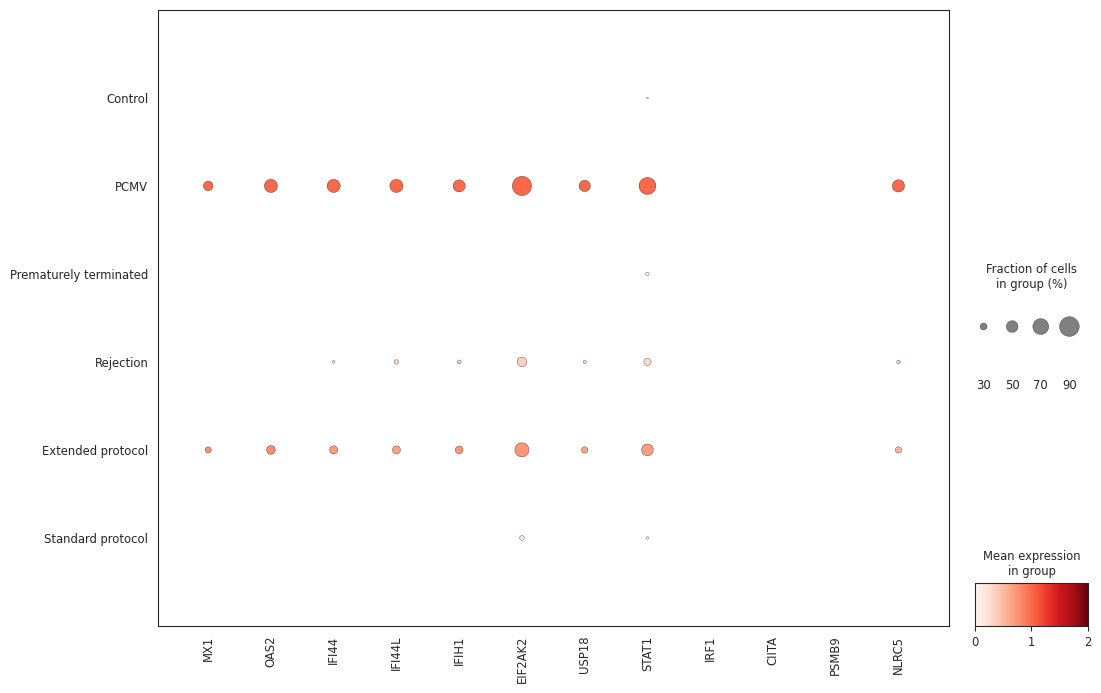

In [64]:
import scanpy as sc
import matplotlib.pyplot as plt

genes_of_interest = ['MX1','OAS2','IFI44','IFI44L','IFIH1','EIF2AK2','USP18','STAT1','IRF1','CIITA','PSMB9','NLRC5'
]

# Ensure 'Condition_subsets' is present in your AnnData object
if 'Condition_subsets' not in global_adata.obs.columns:
    raise ValueError("Condition_subsets column not found in global_adata.obs")

sc.pl.dotplot(
    global_adata,
    var_names=genes_of_interest,
    groupby="Condition_subsets",
    cmap="Reds",
    vmin=0, vmax=2,
    standard_scale='var',   # Scales each gene for better comparison
    dot_min=0.1,            # Only show dots for genes expressed in at least 10% of cells
    figsize=(12, 8)
)
plt.show()


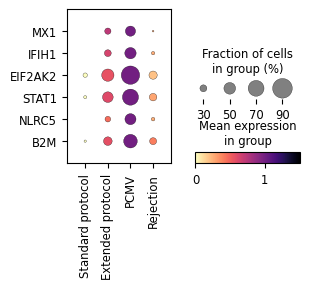

AttributeError: 'NoneType' object has no attribute 'ax_heatmap'

In [39]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

genes_of_interest = ['MX1','IFIH1','EIF2AK2','STAT1','NLRC5', 'B2M']

# Define the desired condition order
condition_order = ['Standard protocol', 'Extended protocol', 'PCMV', 'Rejection']

# Ensure the condition_subsets column is an ordered categorical for control over plotting order
global_adata.obs['Condition_subsets'] = pd.Categorical(
    global_adata.obs['Condition_subsets'],
    categories=condition_order,
    ordered=True
)

# Plot the dotplot
dotplot = sc.pl.dotplot(
    global_adata,
    var_names=genes_of_interest,
    groupby='Condition_subsets',
    cmap='magma_r',                   # perceptually uniform colormap for better contrast
    vmin=0, vmax=1.5,
    standard_scale='var',           # scale each gene for better comparison
    dot_min=0.1,                    # show dots only if expressed in at least 10% cells
    swap_axes=True,                 # genes on y-axis for readability
    figsize=(3, 2)
)

# Additional customization
dotplot.ax_heatmap.set_title('Expression of Selected Genes by Condition Subset', fontsize=16, weight='bold')
dotplot.ax_heatmap.tick_params(axis='x', rotation=45, labelsize=12)
dotplot.ax_heatmap.tick_params(axis='y', labelsize=12)

# Customize colorbar if present
if dotplot.cbar is not None:
    dotplot.cbar.ax.tick_params(labelsize=12)
    dotplot.cbar.set_label('Mean Expression (scaled)', fontsize=14)

plt.tight_layout()
plt.show()


In [17]:
# Calculate gene set scores for each pathway
for pathway_name, gene_list in pathways.items():
    # Filter genes to only those present in the dataset
    genes_in_data = [gene for gene in gene_list if gene in global_adata.var_names]
    
    if len(genes_in_data) > 0:  # Only proceed if there are genes in the dataset
        sc.tl.score_genes(global_adata, gene_list=genes_in_data, score_name=pathway_name + "_score")
    else:
        print(f"No genes from {pathway_name} found in the dataset.")

# Save the AnnData object with the new scores
adata = global_adata.write('/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA_Different_Pathways/GSEA_Metabolic_sets_by_Nastaran/h5ad_Metabolic_pathways_CM_only.h5ad')




In [18]:
adata = sc.read ('/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA_Different_Pathways/GSEA_Metabolic_sets_by_Nastaran/h5ad_Metabolic_pathways_CM_only.h5ad')

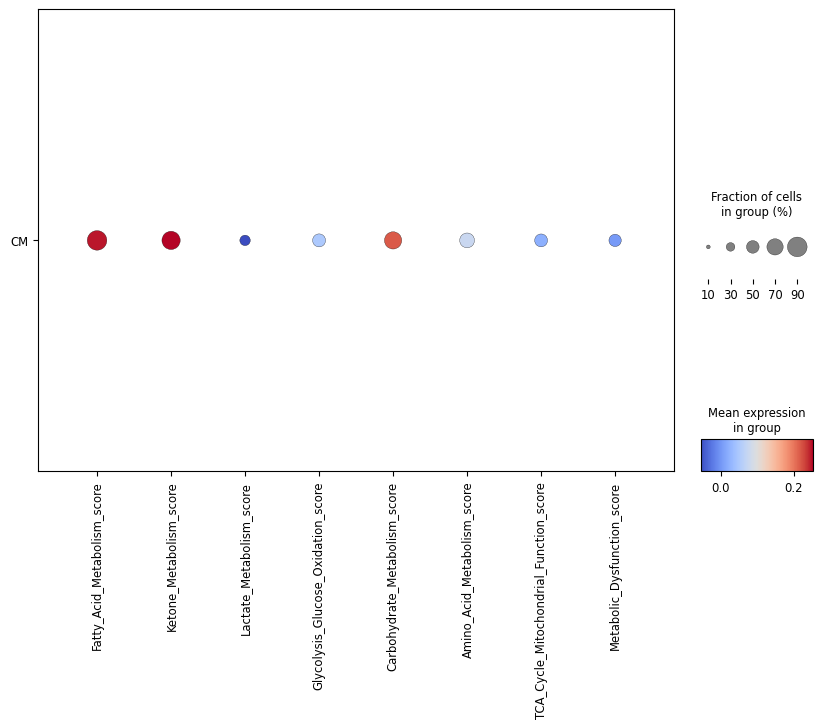

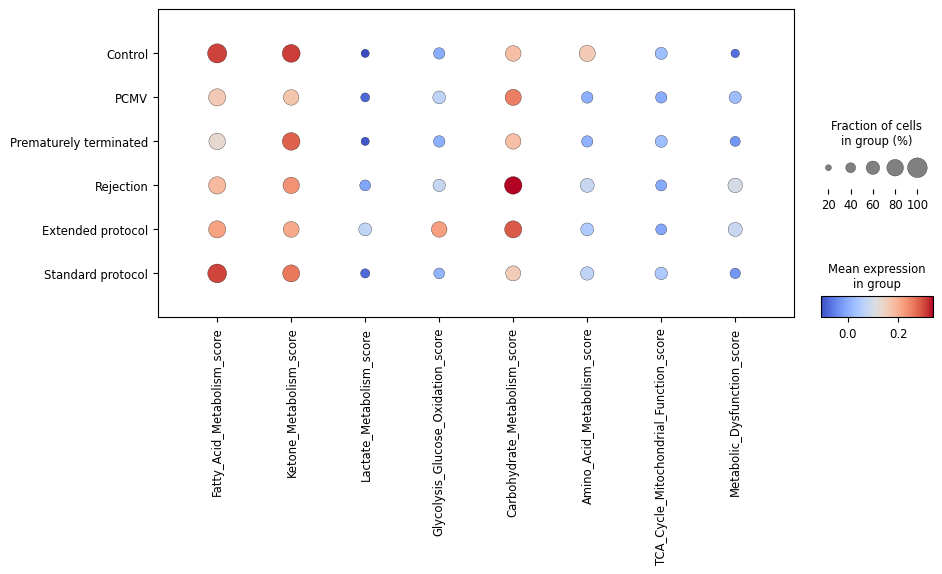

In [20]:
# Plot dot plot of gene set scores by cluster
sc.pl.dotplot(
    adata,
    var_names=[pathway_name + "_score" for pathway_name in pathways.keys()],
    groupby='cell_type',
    cmap='coolwarm',
    figsize=(10, 6)
)

sc.pl.dotplot(
    adata,
    var_names=[pathway_name + "_score" for pathway_name in pathways.keys()],
    groupby='Condition_subsets',
    cmap='coolwarm',
    figsize=(10, 4)
)


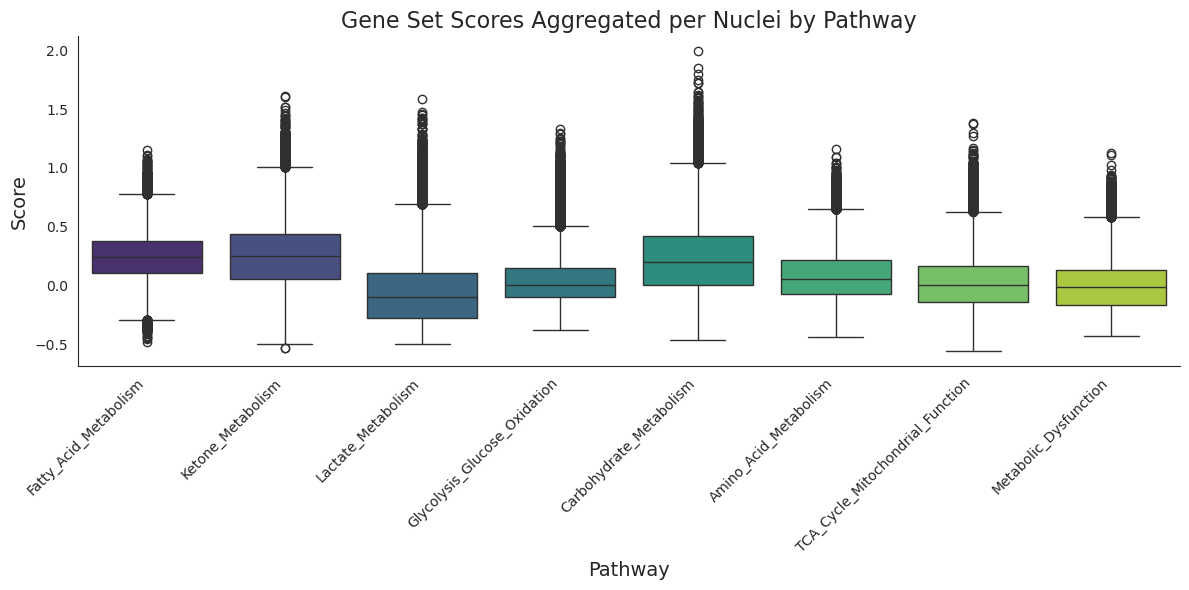

In [21]:
# Create a DataFrame to store the gene set scores
scores_df = pd.DataFrame()

# Extract gene set scores from adata.obs and add to the DataFrame
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Melt the DataFrame for seaborn
scores_df_melted = scores_df.melt(var_name='Pathway', value_name='Score')

# Set style first (before creating the plot)
sns.set_style("white")  # No grid, white background

# Then create your plot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=scores_df_melted,
    x='Pathway',
    y='Score',
    palette='viridis'
)

# Customize as before
plt.title('Gene Set Scores Aggregated per Nuclei by Pathway', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Final cleanup (not strictly needed with "white" style)
ax.grid(False)
sns.despine()

plt.tight_layout()
plt.show()

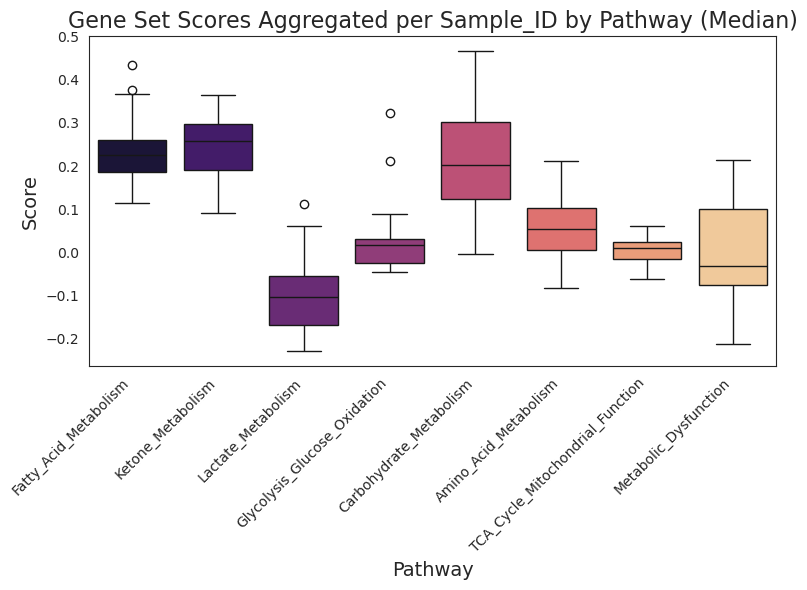

In [22]:
# It shows usean gene set scores across all samples for each pathway
# Create a DataFrame to store the gene set scores and Sample_ID
scores_df = pd.DataFrame()

# Extract gene set scores and Sample_ID
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        # Add the scores and Sample_ID to the DataFrame
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Add the Sample_ID information to the DataFrame
scores_df['Sample_ID'] = adata.obs['Sample_ID']

# Group by Sample_ID and calculate the mean score for each pathway
sample_scores_df = scores_df.groupby('Sample_ID').median()

# Melt the DataFrame for seaborn
sample_scores_melted = sample_scores_df.melt(var_name='Pathway', value_name='Score')

# Create a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    palette='magma'
)

# Customize the plot
plt.title('Gene Set Scores Aggregated per Sample_ID by Pathway (Median)', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

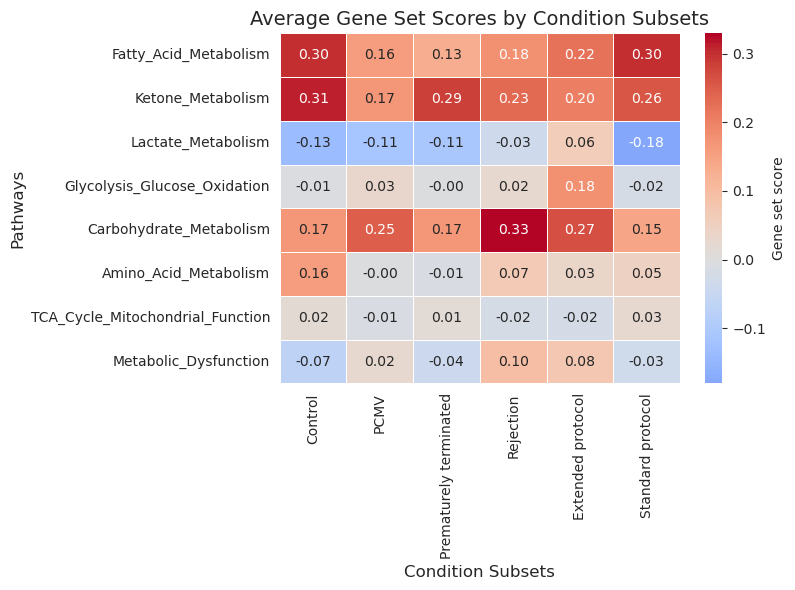

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame with scores and Condition_subsets
scores_df = pd.DataFrame()

# Extract gene set scores and Condition_subsets
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Add the Condition_subsets information
scores_df['Condition_subsets'] = adata.obs['Condition_subsets']

# Group by Condition_subsets and calculate mean scores
condition_scores = scores_df.groupby('Condition_subsets').median()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    condition_scores.T,  # Transpose to have pathways as rows
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=.5,
    cbar_kws={'label': 'Gene set score'}
)

# Customize the plot
plt.title('Average Gene Set Scores by Condition Subsets', fontsize=14)
plt.xlabel('Condition Subsets', fontsize=12)
plt.ylabel('Pathways', fontsize=12)
plt.tight_layout()

plt.show()

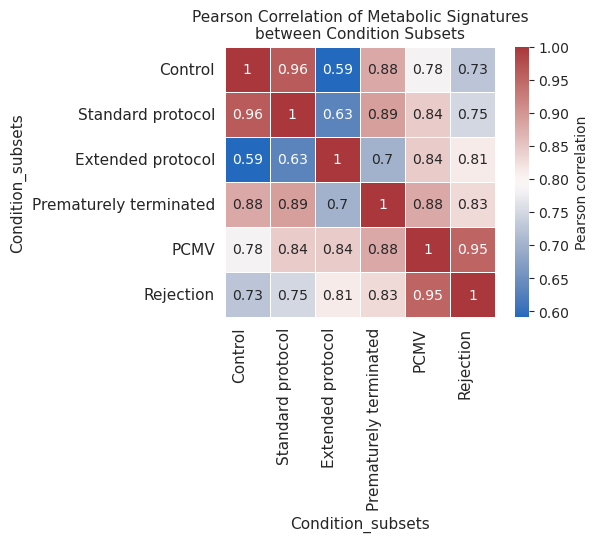

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Condition_subsets and compute the median pathway score
condition_scores = scores_df.groupby('Condition_subsets').median()

# Compute Pearson correlation matrix (Condition_subsets x Condition_subsets)
corr_matrix = condition_scores.T.corr(method='pearson')

# Specify your desired order for Condition_subsets
order = [
    'Control',  
    'Standard protocol', 
    'Extended protocol',
    'Prematurely terminated',
    'PCMV', 
    'Rejection'
]

# Filter to only present groups (avoid KeyError if some are missing)
order = [o for o in order if o in corr_matrix.index]

# Reorder the correlation matrix for axes and legend
corr_matrix = corr_matrix.loc[order, order]

# Get the min/max correlation value for color scaling
cmin = corr_matrix.min().min()
cmax = corr_matrix.max().max()
# Or, set to fixed: cmin, cmax = 0.6, 1.0

plt.figure(figsize=(6.5, 5.4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='vlag',
    vmin=cmin,
    vmax=cmax,
    square=True,
    linewidths=0.5,
    annot_kws={'fontsize':10},
    cbar_kws={'label': 'Pearson correlation'}
)
plt.title('Pearson Correlation of Metabolic Signatures\nbetween Condition Subsets', fontsize=11)
plt.xlabel('Condition_subsets', fontsize=11)
plt.ylabel('Condition_subsets', fontsize=11)
plt.xticks(rotation=90, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Save as PDF
plt.savefig("metabolic_correlation_heatmap.pdf", format='pdf', bbox_inches='tight')

plt.show()


# Spider Plot 

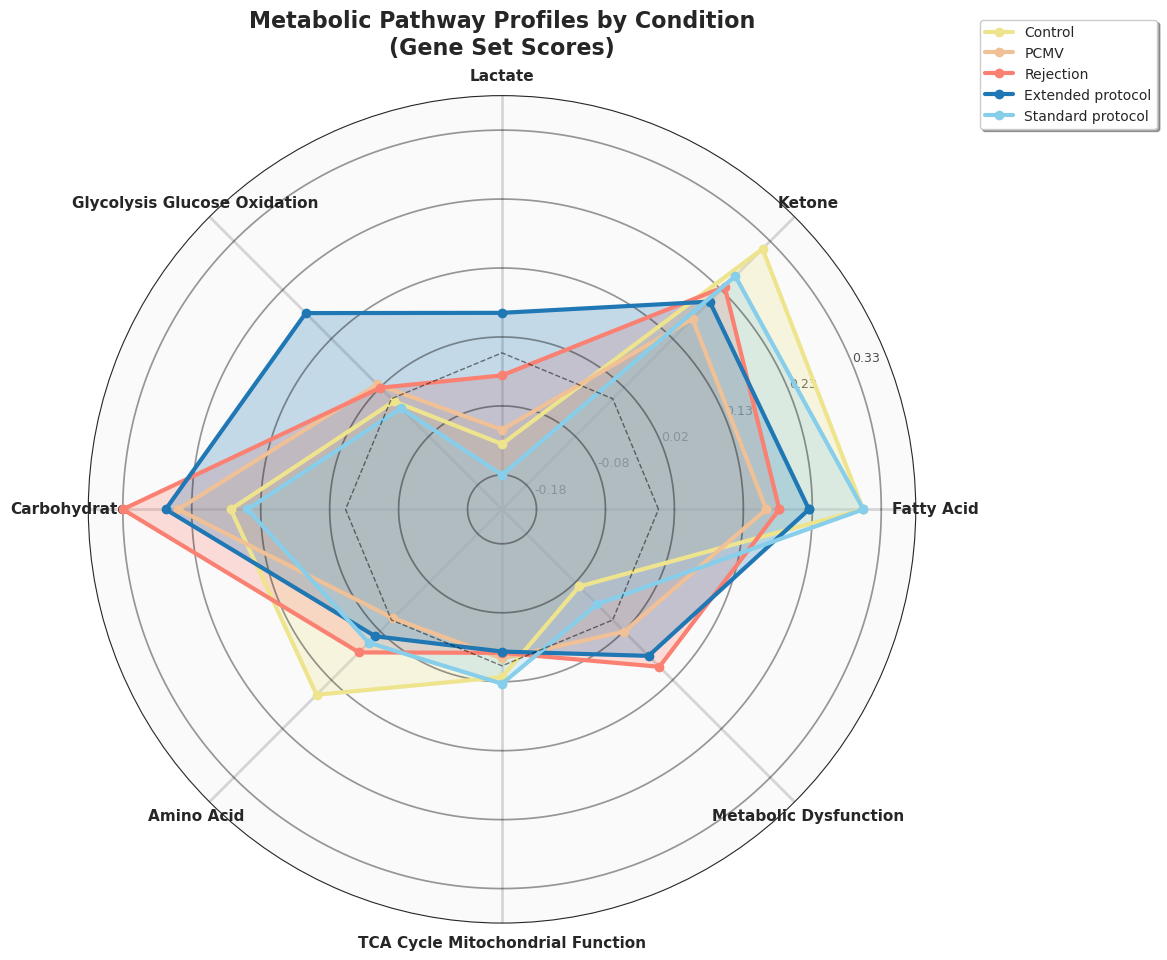


Radar Chart Summary:
Number of conditions: 6
Number of pathways: 8
Score range: -0.180 to 0.329
Conditions shown: ['Control', 'PCMV', 'Prematurely terminated', 'Rejection', 'Extended protocol', 'Standard protocol']


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi

# = YOUR ORIGINAL DATA PREPARATION (UNCHANGED) =
scores_df = pd.DataFrame()

for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

scores_df['Condition_subsets'] = adata.obs['Condition_subsets']
condition_scores = scores_df.groupby('Condition_subsets').median()

# = COLOR PALETTE YOU PROVIDED =
color_palette = {
    'Standard protocol': 'skyblue',
    'Extended protocol': '#1f77b4',  # Using the hex code directly as requested
    'Rejection': 'salmon',
    'PCMV': '#F0C096',
    'Prematurely terminated': '#C9B8D9',
    'Control': '#EFE48E'
}

# = UPDATED RADAR CHART FUNCTION WITH EXCLUDE OPTIONS AND CUSTOM BULLS EYE =
def create_radar_chart(condition_scores, exclude_conditions=None, bulls_eye_linewidth=1.25, bulls_eye_color='black'):
    """
    Create a publication-ready radar/spider chart with custom colors for condition subsets,
    option to exclude condition subsets, and customizable bulls eye line appearance.
    
    Parameters:
    - condition_scores: DataFrame with median scores per Condition_subsets.
    - exclude_conditions: list of condition subset names to exclude (default None).
    - bulls_eye_linewidth: line thickness for bulls eye circles (default 1.25).
    - bulls_eye_color: color of bulls eye circles (default 'black').
    """
    # Filter condition_scores to exclude specified conditions
    if exclude_conditions is not None:
        condition_scores = condition_scores.loc[~condition_scores.index.isin(exclude_conditions)]
    
    pathways = list(condition_scores.columns)
    conditions = list(condition_scores.index)
    N = len(pathways)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Close the circle
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
    
    colors = [color_palette.get(cond, 'grey') for cond in conditions]

    for i, condition in enumerate(conditions):
        values = condition_scores.loc[condition].values.tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=3, label=condition, color=colors[i], markersize=6)
        ax.fill(angles, values, alpha=0.25, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    clean_pathway_names = [p.replace('_', ' ').replace(' Metabolism', '') for p in pathways]
    ax.set_xticklabels(clean_pathway_names, fontsize=11, fontweight='bold')
    
    min_val = condition_scores.min().min()
    max_val = condition_scores.max().max()
    padding = (max_val - min_val) * 0.1
    ax.set_ylim(min_val - padding, max_val + padding)
    
    n_ticks = 6
    tick_values = np.linspace(min_val, max_val, n_ticks)
    ax.set_yticks(tick_values)
    ax.set_yticklabels([f'{val:.2f}' for val in tick_values], fontsize=9, alpha=0.8)

    # Show radial spokes but hide the default concentric circles
    ax.grid(True, axis='x', linewidth=2, alpha=0.8)
    ax.grid(False, axis='y')
    ax.set_facecolor('#fafafa')

    # Draw custom bulls eye concentric circles with specified thickness and color
    for r in tick_values:
        ax.plot(np.linspace(0, 2 * pi, 500), [r] * 500, 
                color=bulls_eye_color, linewidth=bulls_eye_linewidth, alpha=0.4, zorder=1)

    # Zero reference line if 0 crosses data range
    if min_val < 0 < max_val:
        zero_line = [0] * (N + 1)
        ax.plot(angles, zero_line, color='k', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_title('Metabolic Pathway Profiles by Condition\n(Gene Set Scores)', 
                 fontsize=16, fontweight='bold', pad=30)
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=True, fancybox=True, shadow=True)
    plt.tight_layout()
    plt.savefig("metabolic_pathways_CM_only_Spyderplot_Rej_PCMV__Stan_Ext_PLUS_Control.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    
    return fig, ax

# = RUN THE RADAR CHART, EXCLUDING 'Prematurely terminated' & 'PCMV' =
fig, ax = create_radar_chart(condition_scores, exclude_conditions=['Prematurely terminated',])

# Optional: Print summary statistics
print("\nRadar Chart Summary:")
print(f"Number of conditions: {len(condition_scores.index)}")
print(f"Number of pathways: {len(condition_scores.columns)}")
print(f"Score range: {condition_scores.min().min():.3f} to {condition_scores.max().max():.3f}")
print(f"Conditions shown: {list(condition_scores.index)}")
